# Figure 5 — Transport maps between point clouds via barycentric projection

Figures 1–4 transport mixtures; this notebook transports *samples*. 2000 points are drawn
from each of the two mixtures of Figure 1, a Gaussian mixture is re-fitted to each cloud,
entropic partial OT is solved between the fitted components, and the plan is turned back
into a map on points by barycentric projection:

$$
T_b(x) = \frac{\sum_{k,l} \gamma_{kl}\, p_k(x)\, T_{k \to l}(x)}
              {\sum_{k,l} \gamma_{kl}\, p_k(x)},
$$

where $p_k$ is the density of the $k$-th source component and $T_{k \to l}$ the optimal
affine map from component $k$ to component $l$. `pgot.compute_T_X_to_Z_C` does all of this
and returns `Z`, the image of `X`.

Two settings are shown, each twice: once as `X`, `Y` and `Z` overlaid, and once as a strip
of displacement interpolations $(1 - t)X + tZ$ for $t = 0.2, \dots, 1.0$, saved as
`point_reg_{epsilon}_lambda_{Lambda}.eps`.

## Setup

`set_reproducible()` seeds every generator the figures depend on and pins the timestamp
Matplotlib embeds in EPS and PDF output, so re-running the notebook reproduces the same
figures. Run it before anything else.

In [1]:
from pgot import set_reproducible

set_reproducible()

Generator(PCG64) at 0x7FF9266299A0

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pgot import compute_T_X_to_Z_C, sample_from_gmm

## The two mixtures

The same definitions as Figures 1–3: `gmm_A` has two components in the lower left, `gmm_B`
has two in the upper right plus a low-weight outlier at $(9.0, 7.5)$.

In [3]:
# ---------------------------------------
# 1. GMM A (lower left: 2 components)
# ---------------------------------------
alpha_A = np.array([0.5, 0.5])

means_A = np.array(
    [
        [-8.0, -5.0],  # A1
        [1.0, -8.0],  # A2 (lower, slightly to the right)
    ]
)

covs_A = 0.2 * np.array(
    [
        [[1, 0.2], [0.2, 1]],
        [[1, -0.1], [-0.1, 1]],
    ]
)

gmm_A = [2, alpha_A, means_A, covs_A]

# ---------------------------------------
# 2. GMM B (upper right: 2 components + 1 outlier)
# ---------------------------------------
alpha_B = np.array([0.45, 0.45, 0.1])

means_B = np.array(
    [
        [-3.5, 3.5],  # B1
        [3.5, 3.5],  # B2 (same height, to the right)
        [9.0, 7.5],  # B3 (outlier: far to the upper right)
    ]
)

covs_B = 0.2 * np.array(
    [
        [[1, -0.1], [-0.1, 1]],
        [[1, 0.2], [0.2, 1]],
        [[1, 0.0], [0.0, 1]],  # the outlier component is isotropic
    ]
)

gmm_B = [3, alpha_B, means_B, covs_B]

## Sampling

2000 points from each mixture: `X` in red (lower left), `Y` in blue (upper right). About
200 of `Y`'s points land in the outlier component — the cluster the transport map should be
free to ignore.

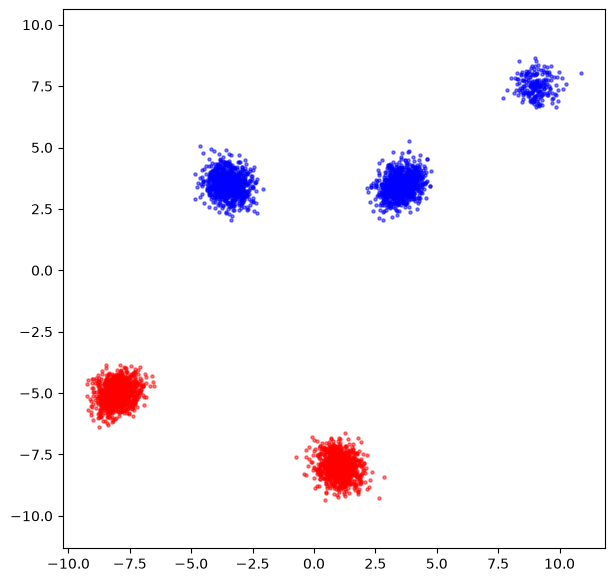

In [4]:
# ---------------------------------------
# Sample from gmm_A -> X (red)
# ---------------------------------------
_, alpha_A, means_A, covs_A = gmm_A
X = sample_from_gmm(alpha_A, means_A, covs_A, N=2000)

# ---------------------------------------
# Sample from gmm_B -> Y (blue)
# ---------------------------------------
_, alpha_B, means_B, covs_B = gmm_B
Y = sample_from_gmm(alpha_B, means_B, covs_B, N=2000)

plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.5)
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.5)
plt.axis("equal")

plt.show()

## $\Lambda = 0.25$, $\varepsilon = 0.03$

`compute_T_X_to_Z_C` re-fits 2 components to `X` and 3 to `Y` — matching the mixtures the
samples came from — solves the entropic partial problem between them and returns the
projected cloud `Z` (green). At this penalty `Z` lands squarely on `B1` and `B2`, and the
outlier cluster is left untouched.

The strip underneath walks the straight-line interpolation $(1 - t)X + tZ$ from `X` to `Z`.

Saves `point_reg_0.03_lambda_0.25.eps`.

[[5.17273491e-03 1.42327459e-01 5.66186119e-07]
 [4.43327265e-01 9.60061216e-04 1.38879439e-11]]
0.5917880863568342


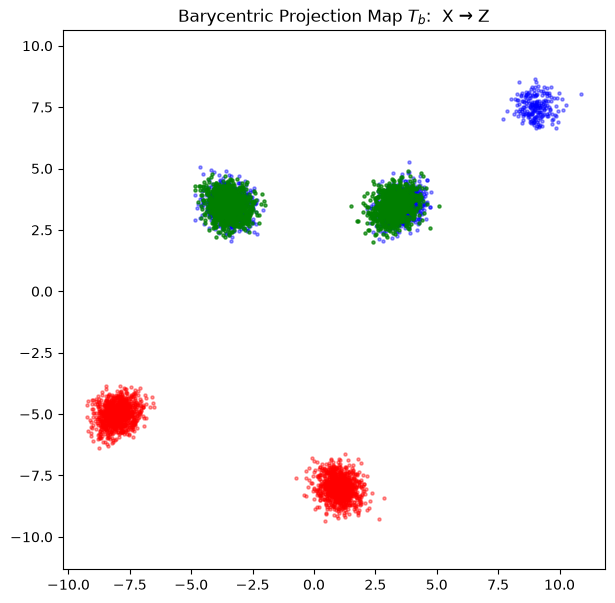

[[ 3.28947947  3.61422254]
 [-3.4902633   4.12615268]
 [ 2.5437606   3.67379828]
 ...
 [-2.62346754  3.25589438]
 [ 2.39090731  2.99147301]
 [ 3.06666693  3.50720523]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


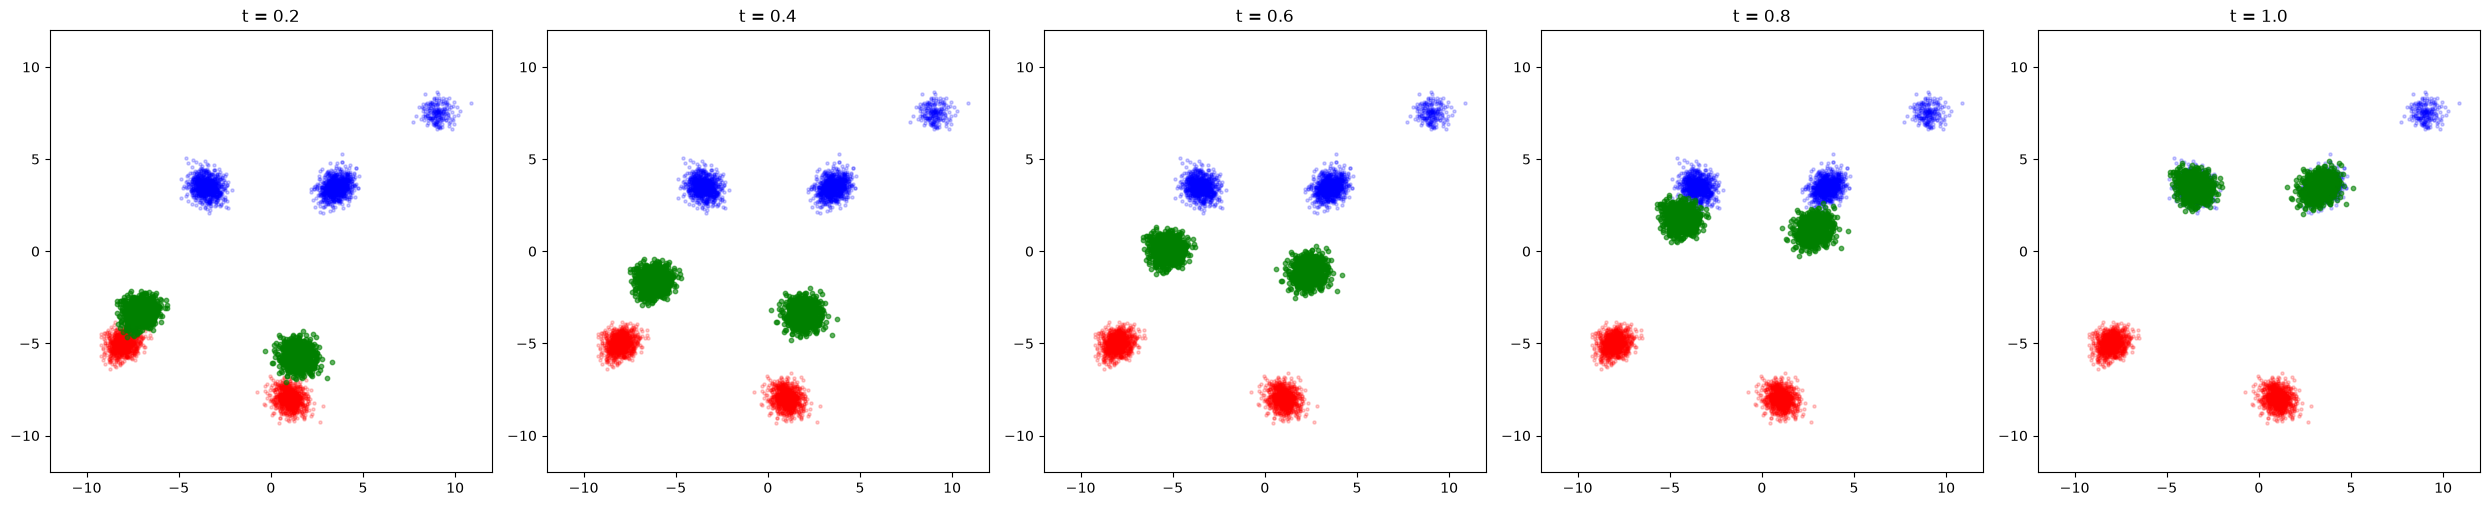

In [5]:
Lambda = 0.25
epsilon = 0.03
# --- Compute Z ---
Z = compute_T_X_to_Z_C(
    X,
    Y,
    n_components_X=2,
    n_components_Y=3,  # matches the mixtures X and Y were sampled from
    epsilon=epsilon,
    Lambda=Lambda,
    nb_dummies=1,
)


# --- Visualization ---
plt.figure(figsize=(7, 7))

xmin, xmax = [-12, 12]
ymin, ymax = [-12, 12]

# Source X (red)
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.4)

# Target Y (blue)
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.4)

# Transported Z (green)
plt.scatter(Z[:, 0], Z[:, 1], s=5, c="green", alpha=0.7)

plt.axis("equal")
plt.title("Barycentric Projection Map $T_b$:  X → Z")
ax_main = plt.gca()

plt.show()
print(Z)


# Interpolation times
ts = np.arange(0.2, 1.01, 0.2)
n_plots = len(ts)

# One panel per t, laid out in a single row
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for i, t in enumerate(ts):
    # Linear interpolation between X and its image Z
    Pt = (1 - t) * X + t * Z

    ax = axes[i]

    # X and Y in the background
    ax.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.2, label="X")
    ax.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.2, label="Y")

    # The interpolated cloud at this t
    ax.scatter(Pt[:, 0], Pt[:, 1], s=10, c="green", alpha=0.6, label="P_t")

    ax.set_title(f"t = {t:.1f}")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


plt.tight_layout()

plt.savefig(
    f"point_reg_{epsilon}_lambda_{Lambda}.eps", format="eps", bbox_inches="tight"
)
plt.show()

## $\Lambda = 0.5$, $\varepsilon = 0.03$

The same call with a larger penalty. Note that `Lambda` is passed to the solver as
`2 * Lambda`, so the value actually used is $1.0$ while the file name written by the next
cell still records $0.5$.

More mass is transported and the image drifts towards the outlier: the right-hand cluster
of `Z` now sits noticeably up and to the right of `B2`, pulled in the direction of `B3`
without reaching it.

[[2.48504640e-04 3.92304900e-01 1.03446595e-01]
 [4.48251495e-01 5.56951000e-02 5.34045134e-05]]
0.999999999879711


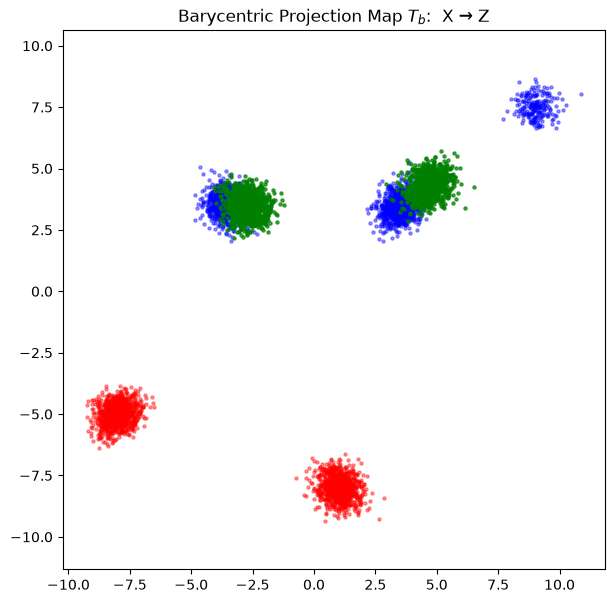

[[ 4.67853818  4.45321526]
 [-2.7139284   4.12537806]
 [ 3.9305276   4.52540293]
 ...
 [-1.86612315  3.27422162]
 [ 3.79161012  3.85270916]
 [ 4.45762978  4.35123259]]


In [6]:
Lambda = 0.5
epsilon = 0.03
# --- Compute Z ---
Z = compute_T_X_to_Z_C(
    X,
    Y,
    n_components_X=2,
    n_components_Y=3,  # matches the mixtures X and Y were sampled from
    epsilon=epsilon,
    Lambda=2 * Lambda,  # the solver sees 1.0; the file name below still says 0.5
    nb_dummies=1,
)


# --- Visualization ---
plt.figure(figsize=(7, 7))

# Source X (red)
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.4)

# Target Y (blue)
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.4)

# Transported Z (green)
plt.scatter(Z[:, 0], Z[:, 1], s=5, c="green", alpha=0.7)

plt.axis("equal")
plt.title("Barycentric Projection Map $T_b$:  X → Z")
ax_main = plt.gca()
xmin, xmax = [-12, 12]
ymin, ymax = [-12, 12]
plt.show()
print(Z)

## Interpolation for the second setting

The same displacement strip for the $\Lambda = 0.5$ map. It reuses `xmin`/`xmax` and
`ymin`/`ymax` from the previous cell, so run the two in order.

Saves `point_reg_0.03_lambda_0.5.eps`.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


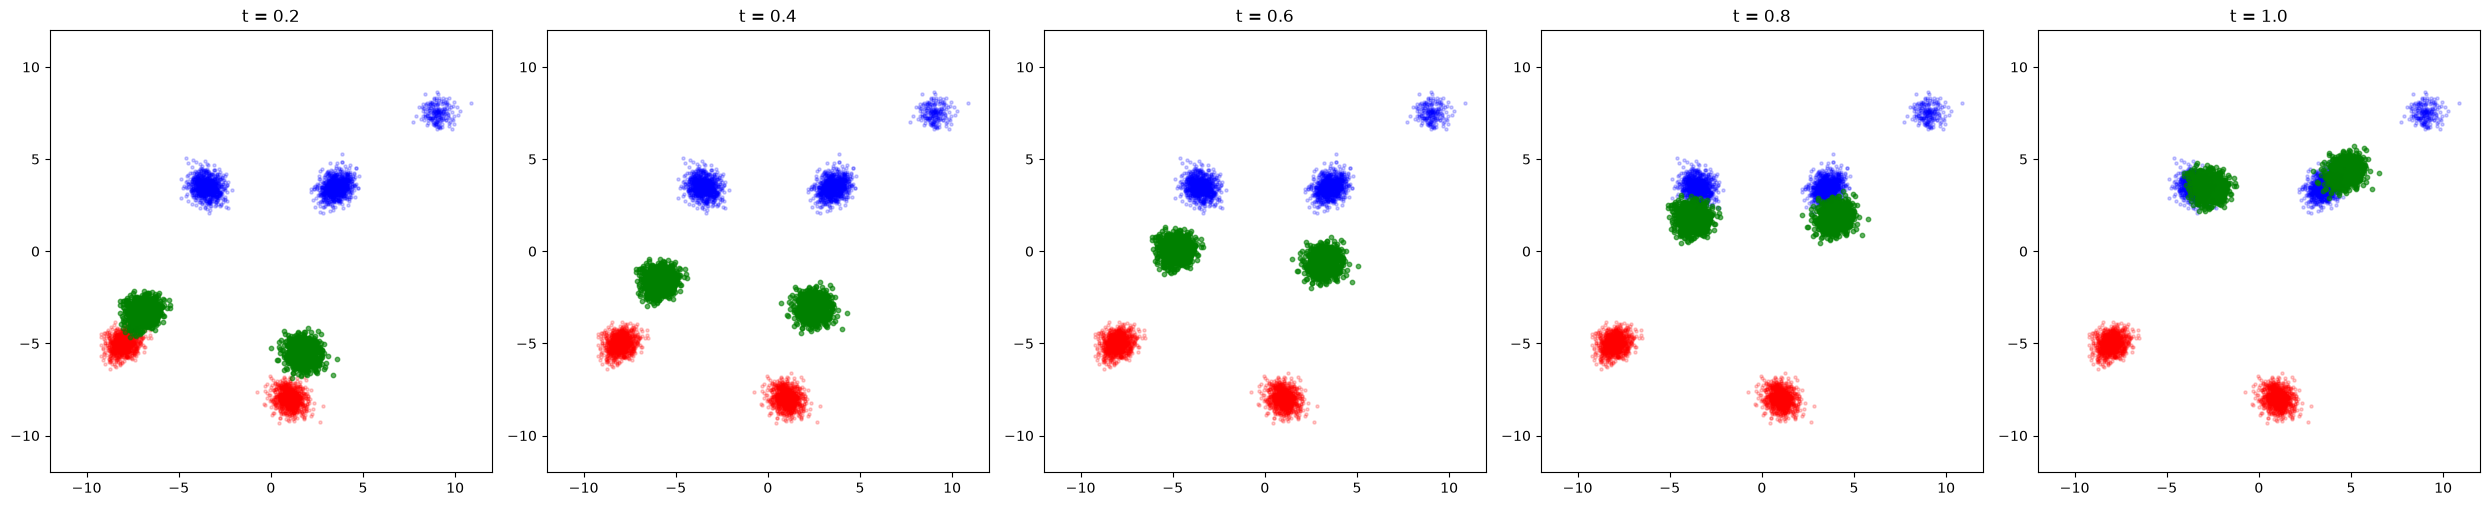

In [7]:
# Interpolation times
ts = np.arange(0.2, 1.01, 0.2)
n_plots = len(ts)

# One panel per t, laid out in a single row
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for i, t in enumerate(ts):
    # Linear interpolation between X and its image Z
    Pt = (1 - t) * X + t * Z

    ax = axes[i]

    # X and Y in the background
    ax.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.2, label="X")
    ax.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.2, label="Y")

    # The interpolated cloud at this t
    ax.scatter(Pt[:, 0], Pt[:, 1], s=10, c="green", alpha=0.6, label="P_t")

    ax.set_title(f"t = {t:.1f}")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


plt.tight_layout()

plt.savefig(
    f"point_reg_{epsilon}_lambda_{Lambda}.eps", format="eps", bbox_inches="tight"
)
plt.show()